# Projet — Régression gaussienne sur le jeu de données Airfoil Self-Noise

Ce notebook a pour objectif d'étudier un modèle de régression gaussienne appliqué au jeu de données **Airfoil Self-Noise** de l'UCI Machine Learning Repository.

On cherche à prédire le niveau de bruit acoustique produit par des profils d’ailes à partir de variables physiques mesurées.

## Plan
1. Chargement du dataset
2. Exploration des données
3. Préparation des variables
4. Implémentation du modèle
5. Évaluation et interprétation
6. Conclusion


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs
import scipy.optimize as sco
import scipy.linalg as sla

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, RBF, WhiteKernel


1. Chargement du dataset

In [4]:
column_names = [
    "frequency",
    "attack_angle",
    "chord_length",
    "free_stream_velocity",
    "suction_side_displacement_thickness",
    "scaled_sound_pressure"
]

df = pd.read_csv(
    "data/airfoil_self_noise.dat",
    sep="\t",
    header=None,
    names=column_names
)

print(df.shape)
display(df.head())

(1503, 6)


,frequency,attack_angle,chord_length,free_stream_velocity,suction_side_displacement_thickness,scaled_sound_pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [6]:
X = df.drop(columns="scaled_sound_pressure")
y = df["scaled_sound_pressure"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (1503, 5)
Dimensions de y : (1503,)


In [10]:
print("Types des variables de X :")
print(X.dtypes)

print("\nTypes de y :")
print(y.dtypes)

print("\nValeurs manquantes dans X :")
print(X.isnull().sum())

print("\nValeurs manquantes dans y :")
print(y.isnull().sum())

Types des variables de X :
frequency                                int64
attack_angle                           float64
chord_length                           float64
free_stream_velocity                   float64
suction_side_displacement_thickness    float64
dtype: object

Types de y :
float64

Valeurs manquantes dans X :
frequency                              0
attack_angle                           0
chord_length                           0
free_stream_velocity                   0
suction_side_displacement_thickness    0
dtype: int64

Valeurs manquantes dans y :
0


In [11]:
display(X.describe())
display(y.describe())

,frequency,attack_angle,chord_length,free_stream_velocity,suction_side_displacement_thickness
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140
std,3152.573137,5.918128,0.093541,15.572784,0.013150
min,200.000000,0.000000,0.025400,31.700000,0.000401
25%,800.000000,2.000000,0.050800,39.600000,0.002535
50%,1600.000000,5.400000,0.101600,39.600000,0.004957
75%,4000.000000,9.900000,0.228600,71.300000,0.015576
max,20000.000000,22.200000,0.304800,71.300000,0.058411


count    1503.000000
mean      124.835943
std         6.898657
min       103.380000
25%       120.191000
50%       125.721000
75%       129.995500
max       140.987000
Name: scaled_sound_pressure, dtype: float64

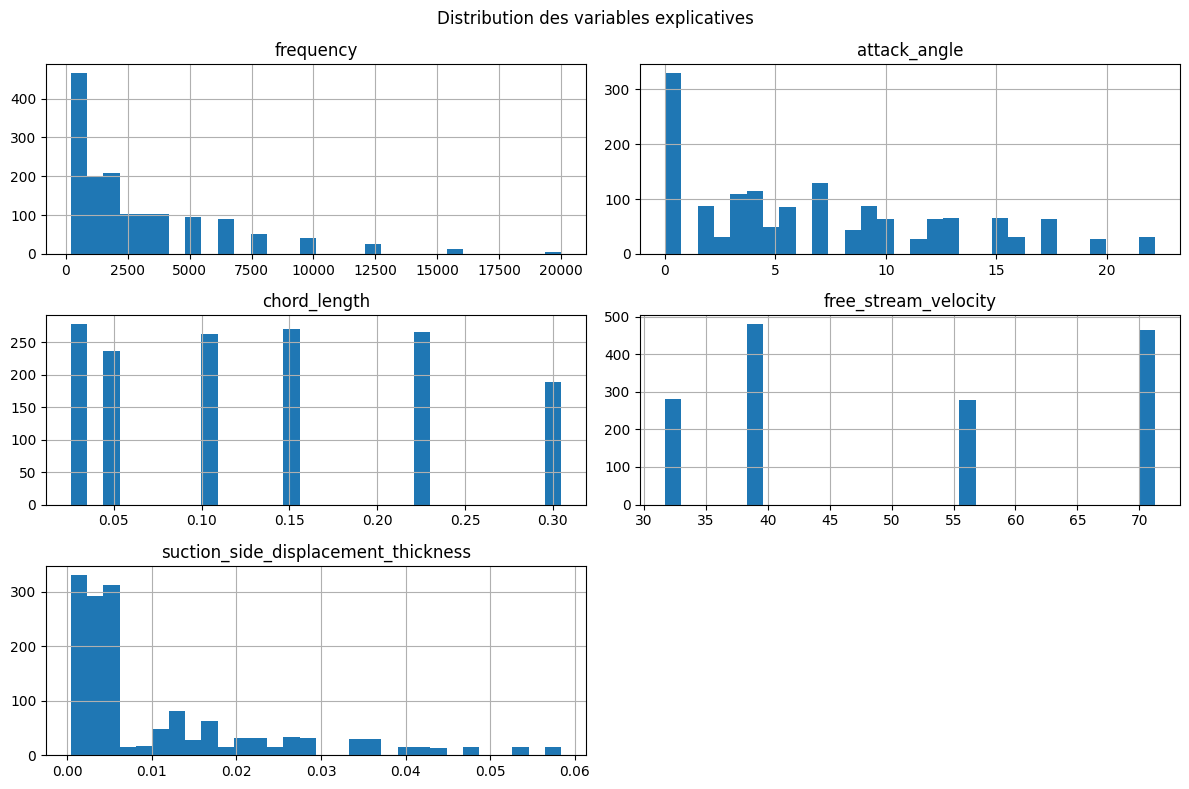

In [12]:
X.hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution des variables explicatives")
plt.tight_layout()
plt.show()

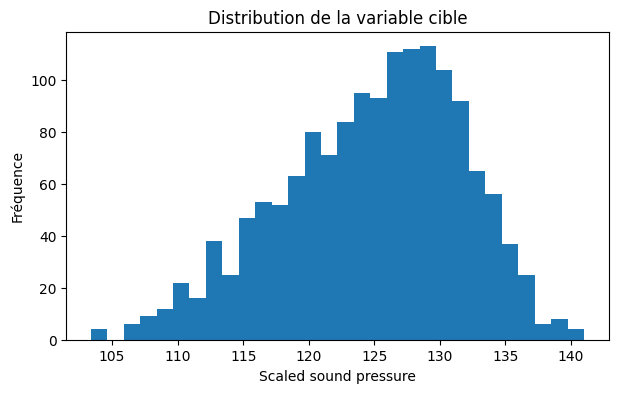

In [14]:
plt.figure(figsize=(7, 4))
plt.hist(y, bins=30)
plt.title("Distribution de la variable cible")
plt.xlabel("Scaled sound pressure")
plt.ylabel("Fréquence")
plt.show()

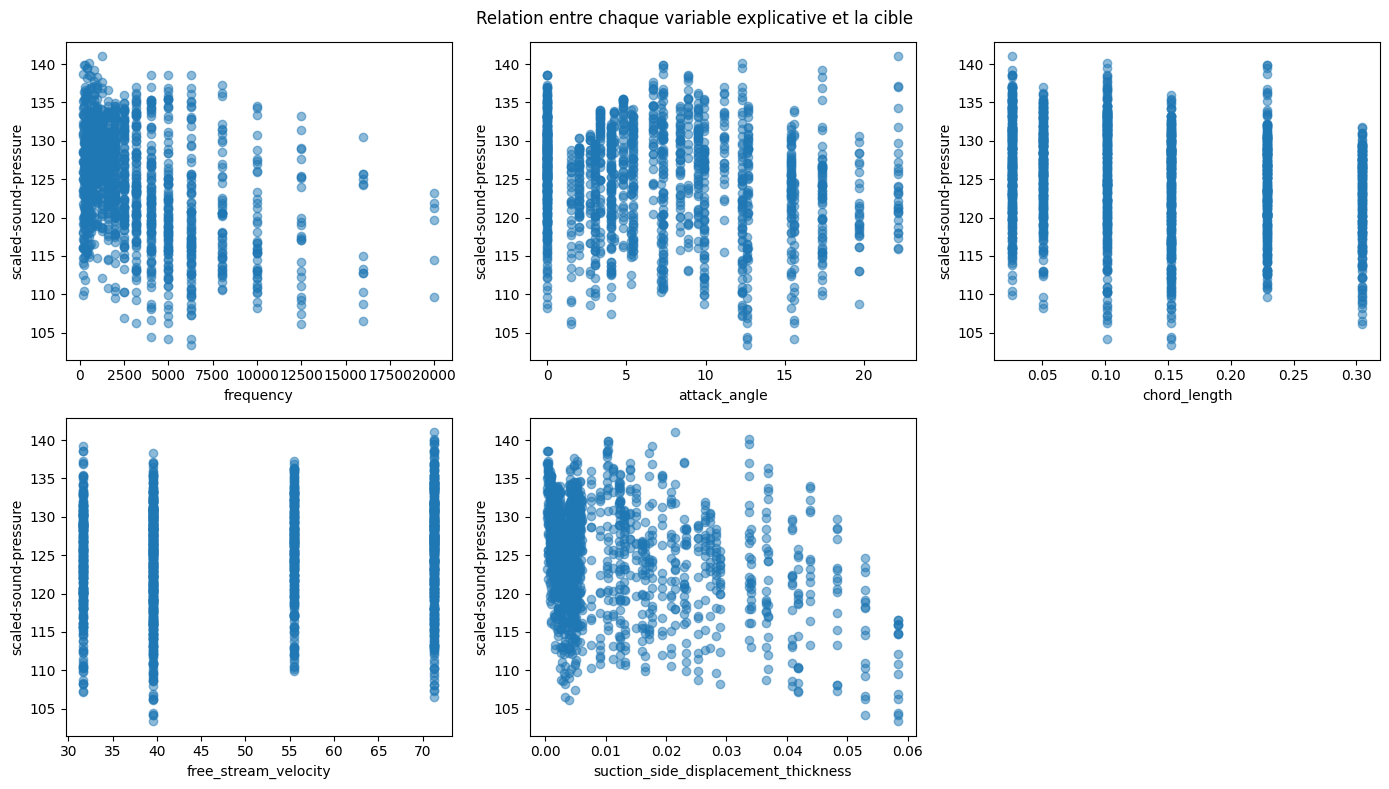

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("scaled-sound-pressure")

fig.delaxes(axes[-1])

plt.suptitle("Relation entre chaque variable explicative et la cible")
plt.tight_layout()
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1202, 5)
X_test  : (301, 5)
y_train : (1202,)
y_test  : (301,)


In [20]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.to_numpy().reshape(-1, 1)).ravel()

print("X_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)
print("y_train_scaled :", y_train_scaled.shape)
print("y_test_scaled  :", y_test_scaled.shape)

X_train_scaled : (1202, 5)
X_test_scaled  : (301, 5)
y_train_scaled : (1202,)
y_test_scaled  : (301,)


In [21]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
display(X_train_scaled_df.describe())

,frequency,attack_angle,chord_length,free_stream_velocity,suction_side_displacement_thickness
count,1.202000e+03,1.202000e+03,1.202000e+03,1.202000e+03,1.202000e+03
mean,5.911337e-18,3.546802e-17,2.866999e-16,3.049881e-16,4.433503e-18
std,1.000416e+00,1.000416e+00,1.000416e+00,1.000416e+00,1.000416e+00
min,-8.370698e-01,-1.159733e+00,-1.200729e+00,-1.258883e+00,-8.202487e-01
25%,-6.491077e-01,-8.169326e-01,-9.288230e-01,-7.517345e-01,-6.562976e-01
50%,-3.984916e-01,-2.341712e-01,-3.850114e-01,2.689825e-01,-4.702344e-01
75%,3.533567e-01,5.371307e-01,9.745177e-01,1.283280e+00,3.048351e-01
max,5.365679e+00,2.645356e+00,1.790235e+00,1.283280e+00,3.635700e+00


Le dataset contient 1503 observations et 5 variables explicatives numériques. La variable cible correspond au niveau de bruit acoustique.

Les statistiques descriptives montrent que les variables explicatives sont sur des échelles très différentes, ce qui justifie une standardisation avant l'entraînement des modèles.

Les histogrammes indiquent que certaines variables sont très asymétriques (`frequency`, `suction_side_displacement_thickness`) tandis que d'autres prennent seulement quelques valeurs distinctes (`chord_length`, `free_stream_velocity`).

Les nuages de points suggèrent que plusieurs variables ont une relation visible avec la cible, mais que ces relations ne semblent pas strictement linéaires. Cela motive l'utilisation d'un modèle flexible de type processus gaussien.

## Passage à la modélisation

Après cette phase d'exploration, nous passons à l'apprentissage d'un modèle de régression gaussienne sur le jeu de données Airfoil.  
L'objectif est de prédire la variable `scaled_sound_pressure` à partir des variables explicatives, tout en obtenant également une mesure d'incertitude sur les prédictions.

In [36]:
# Régression linéaire de base
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train_scaled)

y_pred_linear = linear_model.predict(X_test_scaled)

linear_results = {
    "RMSE": np.sqrt(mean_squared_error(y_test_scaled, y_pred_linear)),
    "MAE": mean_absolute_error(y_test_scaled, y_pred_linear),
    "R2": r2_score(y_test_scaled, y_pred_linear)
}

pd.DataFrame([linear_results], index=["Linear Regression"])

,RMSE,MAE,R2
Linear Regression,0.686781,0.536158,0.558298


Cette première régression linéaire sert de point de comparaison.  
Elle permet d'évaluer si la régression gaussienne apporte un réel gain de performance sur ce jeu de données.

In [37]:
from sklearn.gaussian_process.kernels import DotProduct

kernel_linear = DotProduct()

gp_linear = GaussianProcessRegressor(
    kernel=kernel_linear,
    random_state=42,
    n_restarts_optimizer=5
)

gp_linear.fit(X_train_scaled, y_train_scaled)

y_pred_linear, y_std_linear = gp_linear.predict(X_test_scaled, return_std=True)

print("Noyau appris :", gp_linear.kernel_)
print("Shape prédictions :", y_pred_linear.shape)
print("Shape std :", y_std_linear.shape)

Noyau appris : DotProduct(sigma_0=9.7)
Shape prédictions : (301,)
Shape std : (301,)


On commence par un processus gaussien muni d’un noyau linéaire simple.  
Ce premier modèle permet de tester si une structure globalement linéaire peut déjà expliquer la variable cible à partir des variables explicatives.

In [38]:
from sklearn.gaussian_process.kernels import WhiteKernel

kernel_linear_noise = DotProduct() + WhiteKernel()

gp_linear_noise = GaussianProcessRegressor(
    kernel=kernel_linear_noise,
    random_state=42,
    n_restarts_optimizer=5
)

gp_linear_noise.fit(X_train_scaled, y_train_scaled)

y_pred_linear_noise, y_std_linear_noise = gp_linear_noise.predict(X_test_scaled, return_std=True)

print("Noyau appris :", gp_linear_noise.kernel_)

Noyau appris : DotProduct(sigma_0=3.81e-05) + WhiteKernel(noise_level=0.499)


On enrichit ensuite le noyau linéaire par un terme de bruit blanc (`WhiteKernel`).  
Cela permet au modèle de mieux prendre en compte la variabilité résiduelle des observations et d’éviter une modélisation trop rigide.

In [39]:
rmse_linear_noise = np.sqrt(mean_squared_error(y_test_scaled, y_pred_linear_noise))
mae_linear_noise = mean_absolute_error(y_test_scaled, y_pred_linear_noise)
r2_linear_noise = r2_score(y_test_scaled, y_pred_linear_noise)

# Variance prédictive
var_linear_noise = y_std_linear_noise**2
eps = 1e-8
var_linear_noise = np.maximum(var_linear_noise, eps)

# Mean log-likelihood
log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_linear_noise) +
    (y_test_scaled - y_pred_linear_noise) ** 2 / var_linear_noise
)
mean_log_likelihood_linear_noise = np.mean(log_likelihoods)

results_linear_noise = pd.DataFrame({
    "RMSE": [rmse_linear_noise],
    "MAE": [mae_linear_noise],
    "R2": [r2_linear_noise],
    "Mean log-likelihood": [mean_log_likelihood_linear_noise]
}, index=["GP linéaire + bruit"])

results_linear_noise

,RMSE,MAE,R2,Mean log-likelihood
GP linéaire + bruit,0.686844,0.536262,0.558218,-1.043655


Les résultats montrent que le processus gaussien à noyau linéaire avec bruit capture une partie non négligeable de la structure des données, avec un coefficient de détermination R² d’environ 0.56.  
Ce niveau de performance reste toutefois modéré, ce qui suggère qu’un noyau plus flexible pourrait mieux modéliser les relations entre les variables explicatives et la cible.

In [41]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

kernel_rbf_noise = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)

gp_rbf_noise = GaussianProcessRegressor(
    kernel=kernel_rbf_noise,
    random_state=42,
    n_restarts_optimizer=5
)

gp_rbf_noise.fit(X_train_scaled, y_train_scaled)

y_pred_rbf_noise, y_std_rbf_noise = gp_rbf_noise.predict(X_test_scaled, return_std=True)

print("Noyau appris :", gp_rbf_noise.kernel_)


Noyau appris : 1.98**2 * RBF(length_scale=1.12) + WhiteKernel(noise_level=0.109)


Après l’étude d’un noyau linéaire avec bruit, on considère maintenant un noyau RBF avec bruit blanc.  
Ce noyau est plus flexible et permet de modéliser des relations non linéaires entre les variables explicatives et la variable cible.

In [42]:

rmse_rbf_noise = np.sqrt(mean_squared_error(y_test_scaled, y_pred_rbf_noise))
mae_rbf_noise = mean_absolute_error(y_test_scaled, y_pred_rbf_noise)
r2_rbf_noise = r2_score(y_test_scaled, y_pred_rbf_noise)

var_rbf_noise = y_std_rbf_noise**2
eps = 1e-8
var_rbf_noise = np.maximum(var_rbf_noise, eps)

log_likelihoods_rbf = -0.5 * (
    np.log(2 * np.pi * var_rbf_noise) +
    (y_test_scaled - y_pred_rbf_noise) ** 2 / var_rbf_noise
)
mean_log_likelihood_rbf_noise = np.mean(log_likelihoods_rbf)

results_rbf_noise = pd.DataFrame({
    "RMSE": [rmse_rbf_noise],
    "MAE": [mae_rbf_noise],
    "R2": [r2_rbf_noise],
    "Mean log-likelihood": [mean_log_likelihood_rbf_noise]
}, index=["GP RBF + bruit"])

results_rbf_noise

,RMSE,MAE,R2,Mean log-likelihood
GP RBF + bruit,0.34399,0.239176,0.889189,-0.380967


Les résultats montrent que le processus gaussien muni d’un noyau RBF avec bruit surpasse nettement le modèle à noyau linéaire avec bruit.  
Les erreurs de prédiction (RMSE et MAE) sont plus faibles, le coefficient de détermination R² est nettement plus élevé, et la log-vraisemblance prédictive moyenne est meilleure.

Cette comparaison suggère que la relation entre les variables explicatives et la variable cible n’est pas purement linéaire.  
Le noyau RBF, plus flexible, semble donc mieux adapté à la structure du jeu de données Airfoil.

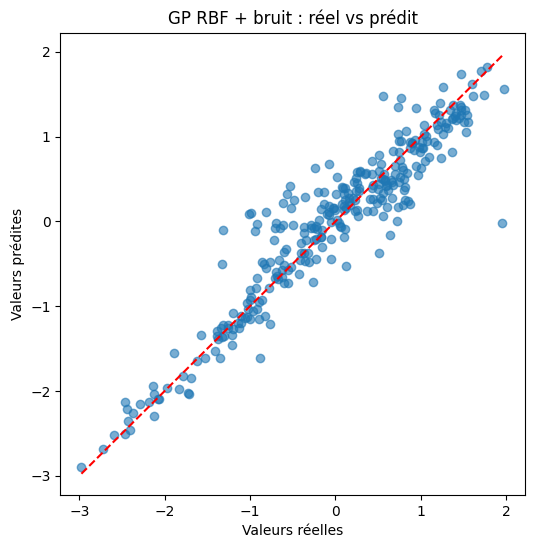

In [47]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_scaled, y_pred_rbf_noise, alpha=0.6)
plt.plot(
    [y_test_scaled.min(), y_test_scaled.max()],
    [y_test_scaled.min(), y_test_scaled.max()],
    "r--"
)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("GP RBF + bruit : réel vs prédit")
plt.savefig("Fig/RBF + bruit : réel vs prédit.png")
plt.show()

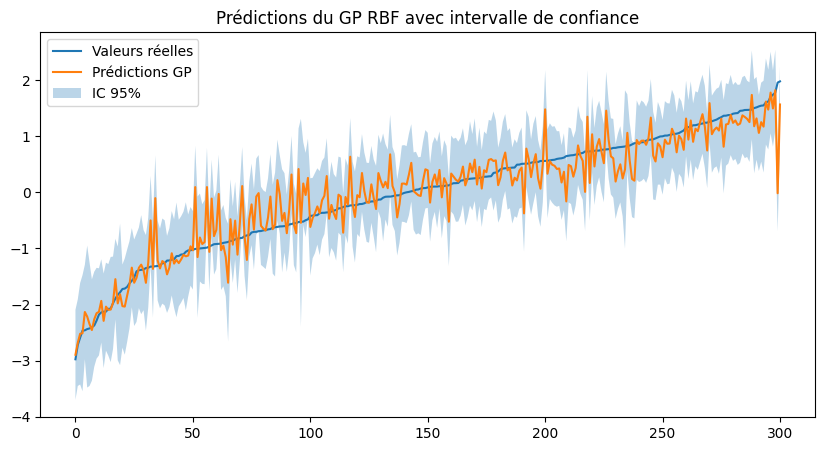

In [46]:
order = np.argsort(y_test_scaled)

plt.figure(figsize=(10, 5))
plt.plot(y_test_scaled[order], label="Valeurs réelles")
plt.plot(y_pred_rbf_noise[order], label="Prédictions GP")
plt.fill_between(
    np.arange(len(y_pred_rbf_noise)),
    y_pred_rbf_noise[order] - 1.96 * y_std_rbf_noise[order],
    y_pred_rbf_noise[order] + 1.96 * y_std_rbf_noise[order],
    alpha=0.3,
    label="IC 95%"
)
plt.legend()
plt.title("Prédictions du GP RBF avec intervalle de confiance")
plt.savefig("Fig/Prédictions du GP RBF avec intervalle de confiance.png")
plt.show()

Ce graphique permet de visualiser simultanément les valeurs réelles, les prédictions du modèle et l’incertitude associée.  
Après tri des observations, on constate que le processus gaussien à noyau RBF suit correctement la tendance générale de la cible.  
La bande de confiance à 95 % illustre l’un des principaux intérêts du modèle : fournir non seulement une prédiction moyenne, mais aussi une estimation de l’incertitude.

## Conclusion

Dans ce notebook, nous avons appliqué la régression gaussienne au jeu de données *Airfoil Self-Noise*.  
Après une analyse exploratoire des variables, nous avons entraîné et comparé deux processus gaussiens : un modèle à noyau linéaire avec bruit et un modèle à noyau RBF avec bruit.

Les résultats montrent que le modèle à noyau RBF avec bruit est nettement plus performant.  
Il obtient des erreurs de prédiction plus faibles, un coefficient de détermination R² plus élevé, ainsi qu’une meilleure log-vraisemblance prédictive moyenne.  
Cela suggère que les relations entre les variables explicatives et la variable cible ne sont pas purement linéaires, et qu’un noyau plus flexible est mieux adapté à ce problème.